<a href="https://colab.research.google.com/github/khu3086/NeuralFieldsImplementation/blob/main/OccupancyNetworksImplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Occupancy Networks

## Occupancy Networks (Mescheder et al., 2019)
Learning Continuous 3D Surface Representations as a Function of Space


Core idea: Instead of representing 3D shapes as voxels (memory: O(N³)), point clouds (no surface), or meshes (topology restrictions), an Occupancy Network learns a *continuous function*:

$$f_\theta : \mathbb{R}^3 \rightarrow [0, 1]$$

For any 3D point **p**, the network outputs the probability that **p** is *inside* the shape. The 3D surface is the **decision boundary** at threshold 0.5.

1. 🏗️ The ONet architecture (ResNet blocks + Conditional Batch Norm)
2. 🎯 Training to overfit a single shape (sphere, torus, box)
3. 🧊 Mesh extraction via Marching Cubes
4. 🔀 Latent space interpolation between shapes
5. 📊 Comparison to voxel representation

Reference: [arXiv:1812.03828](https://arxiv.org/abs/1812.03828)

## 1. Install Dependencies

In [7]:
!pip install -q scikit-image trimesh plotly

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure
import plotly.graph_objects as go
import trimesh

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)

Using device: cuda


## 2. Ground-Truth Shape Samplers

We define analytic shapes and sample points with occupancy labels (1 = inside, 0 = outside). In practice you'd load meshes from ShapeNet.

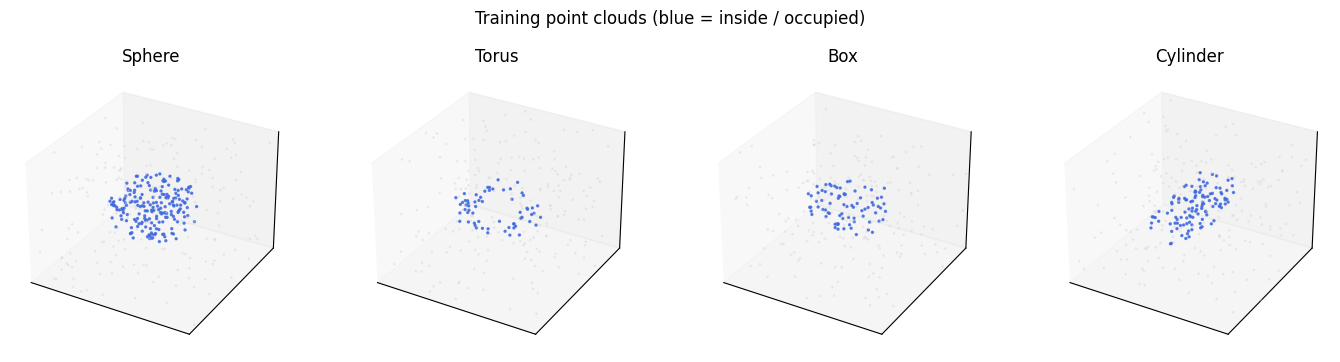

In [9]:
def sample_sphere(n_points, radius=0.5, noise=0.0):
    """Sample points uniformly in [-1,1]^3 and label based on unit sphere."""
    pts = torch.rand(n_points, 3) * 2 - 1
    r = pts.norm(dim=-1)
    occ = (r < radius).float()
    if noise > 0:
        pts = pts + torch.randn_like(pts) * noise
    return pts, occ

def sample_torus(n_points, R=0.4, r=0.15):
    """Points labeled inside a torus with major radius R, minor radius r."""
    pts = torch.rand(n_points, 3) * 2 - 1
    x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]
    # Torus equation: (sqrt(x^2+y^2) - R)^2 + z^2 < r^2
    dist = (torch.sqrt(x**2 + y**2) - R)**2 + z**2
    occ = (dist < r**2).float()
    return pts, occ

def sample_box(n_points, half_extents=(0.4, 0.25, 0.3)):
    """Points labeled inside an axis-aligned box."""
    pts = torch.rand(n_points, 3) * 2 - 1
    hx, hy, hz = half_extents
    inside = (pts[:, 0].abs() < hx) & (pts[:, 1].abs() < hy) & (pts[:, 2].abs() < hz)
    occ = inside.float()
    return pts, occ

def sample_cylinder(n_points, radius=0.3, height=0.6):
    """Points labeled inside a cylinder aligned along Y axis."""
    pts = torch.rand(n_points, 3) * 2 - 1
    r_xz = torch.sqrt(pts[:, 0]**2 + pts[:, 2]**2)
    inside = (r_xz < radius) & (pts[:, 1].abs() < height)
    occ = inside.float()
    return pts, occ

SHAPES = {
    'sphere':   sample_sphere,
    'torus':    sample_torus,
    'box':      sample_box,
    'cylinder': sample_cylinder,
}

# Quick visualisation of the training data
fig = plt.figure(figsize=(14, 3.5))
for i, (name, fn) in enumerate(SHAPES.items()):
    pts, occ = fn(3000)
    inside  = pts[occ == 1]
    outside = pts[occ == 0]
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    ax.scatter(*outside[:200].T, c='lightgray', s=1, alpha=0.3)
    ax.scatter(*inside[:200].T,  c='royalblue', s=2, alpha=0.8)
    ax.set_title(name.capitalize())
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlim(-1,1); ax.set_ylim(-1,1); ax.set_zlim(-1,1)
plt.suptitle('Training point clouds (blue = inside / occupied)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Occupancy Network Architecture

The paper uses **5 ResNet blocks** with **Conditional Batch Normalization** (CBN) to inject the shape latent code `z` at every block. Here we implement the full architecture faithfully:

```
Input: point p ∈ ℝ³,  latent code z ∈ ℝᴸ
  ↓  Linear(3 → 256)
  ↓  ResNetBlock(z) × 5   ← CBN fuses z at each block
  ↓  Linear(256 → 1) + Sigmoid
Output: occupancy probability ∈ [0, 1]
```

In [10]:
# ── Conditional Batch Normalization ────────────────────────────────────────────
class CBatchNorm1d(nn.Module):
    """
    Conditional Batch Norm for 1D features.
    Learns per-sample gamma and beta from the latent code z.
    """
    def __init__(self, c_dim, f_dim):
        super().__init__()
        self.f_dim = f_dim
        self.bn = nn.BatchNorm1d(f_dim, affine=False)  # no learnable gamma/beta
        self.gamma_fc = nn.Linear(c_dim, f_dim)        # conditioned gamma
        self.beta_fc  = nn.Linear(c_dim, f_dim)        # conditioned beta
        # Init so CBN starts as identity
        nn.init.ones_(self.gamma_fc.weight)
        nn.init.zeros_(self.gamma_fc.bias)
        nn.init.zeros_(self.beta_fc.weight)
        nn.init.zeros_(self.beta_fc.bias)

    def forward(self, x, z):
        # x: (B, T, f_dim)  — batch of points
        # z: (B, c_dim)     — per-shape latent
        B, T, F = x.shape
        # Flatten for BN, then restore
        x_flat = x.reshape(B * T, F)
        x_norm = self.bn(x_flat).reshape(B, T, F)
        gamma = self.gamma_fc(z).unsqueeze(1)   # (B,1,F)
        beta  = self.beta_fc(z).unsqueeze(1)    # (B,1,F)
        return gamma * x_norm + beta


# ── ResNet Block ───────────────────────────────────────────────────────────────
class ResnetBlockFC(nn.Module):
    """
    Fully-connected ResNet block conditioned on latent z via CBN.
    Matches the paper's architecture (size_in = size_out = size_h = 256).
    """
    def __init__(self, size_in, c_dim, size_out=None, size_h=None):
        super().__init__()
        size_out = size_out or size_in
        size_h   = size_h   or min(size_in, size_out)

        self.fc0  = nn.Linear(size_in,  size_h)
        self.fc1  = nn.Linear(size_h,   size_out)
        self.bn0  = CBatchNorm1d(c_dim, size_in)
        self.bn1  = CBatchNorm1d(c_dim, size_h)

        # Shortcut projection if sizes differ
        self.shortcut = nn.Linear(size_in, size_out, bias=False) if size_in != size_out else None
        nn.init.zeros_(self.fc1.weight)   # init last layer to 0 → identity at start

    def forward(self, x, z):
        # x: (B, T, size_in)
        h = F.relu(self.bn0(x, z))
        h = self.fc0(h)
        h = F.relu(self.bn1(h, z))
        h = self.fc1(h)
        if self.shortcut:
            x = self.shortcut(x)
        return x + h


# ── Occupancy Decoder ──────────────────────────────────────────────────────────
class OccupancyDecoder(nn.Module):
    """
    The core ONet decoder: maps (p, z) → occupancy ∈ [0,1].

    Args:
        c_dim:          dimensionality of latent code z
        hidden_size:    width of ResNet blocks (256 in paper)
        n_blocks:       number of ResNet blocks (5 in paper)
    """
    def __init__(self, c_dim=128, hidden_size=256, n_blocks=5):
        super().__init__()
        self.fc_p   = nn.Linear(3, hidden_size)   # point embedding
        self.blocks = nn.ModuleList([
            ResnetBlockFC(hidden_size, c_dim) for _ in range(n_blocks)
        ])
        self.bn_out = CBatchNorm1d(c_dim, hidden_size)
        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, p, z):
        """
        p: (B, T, 3)   — query points
        z: (B, c_dim)  — shape latent
        Returns: (B, T) occupancy logits
        """
        h = self.fc_p(p)                     # (B, T, hidden)
        for block in self.blocks:
            h = block(h, z)
        h = F.relu(self.bn_out(h, z))
        out = self.fc_out(h).squeeze(-1)     # (B, T)
        return torch.sigmoid(out)


# ── Simple PointNet Encoder (optional — for shape conditioning) ────────────────
class PointNetEncoder(nn.Module):
    """
    Lightweight PointNet-style encoder: point cloud → latent z.
    In our unconditional demo, z is a learned embedding; this encoder
    is used in the interpolation section.
    """
    def __init__(self, c_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, c_dim)

    def forward(self, pts):
        # pts: (B, N, 3)
        h = F.relu(self.fc1(pts))
        h = F.relu(self.fc2(h))
        h = self.fc3(h)
        z, _ = h.max(dim=1)   # global max-pool → (B, c_dim)
        return z


print('✅ ONet architecture defined!')
# Quick parameter count
dec = OccupancyDecoder(c_dim=128, hidden_size=256, n_blocks=5)
params = sum(p.numel() for p in dec.parameters())
print(f'   Decoder parameters: {params:,}')

✅ ONet architecture defined!
   Decoder parameters: 1,385,729


## 4. Training: Overfit a Single Shape

For demonstration we train the ONet (with a fixed learned latent `z`) to overfit one shape at a time. The loss is **binary cross-entropy** between predicted occupancy and ground truth labels.

Training ONet on sphere...
  Step  500 | BCE Loss: 0.6928 | Accuracy: 0.936
  Step 1000 | BCE Loss: 0.6715 | Accuracy: 0.941
  Step 1500 | BCE Loss: 0.6617 | Accuracy: 0.932
  Step 2000 | BCE Loss: 0.6519 | Accuracy: 0.931
  Step 2500 | BCE Loss: 0.6464 | Accuracy: 0.935
  Step 3000 | BCE Loss: 0.6418 | Accuracy: 0.932

Training ONet on torus...
  Step  500 | BCE Loss: 0.6530 | Accuracy: 0.979
  Step 1000 | BCE Loss: 0.6311 | Accuracy: 0.977
  Step 1500 | BCE Loss: 0.6213 | Accuracy: 0.971
  Step 2000 | BCE Loss: 0.6087 | Accuracy: 0.982
  Step 2500 | BCE Loss: 0.6047 | Accuracy: 0.976
  Step 3000 | BCE Loss: 0.5993 | Accuracy: 0.976

Training ONet on box...
  Step  500 | BCE Loss: 0.6448 | Accuracy: 0.970
  Step 1000 | BCE Loss: 0.6235 | Accuracy: 0.969
  Step 1500 | BCE Loss: 0.6130 | Accuracy: 0.969
  Step 2000 | BCE Loss: 0.6028 | Accuracy: 0.969
  Step 2500 | BCE Loss: 0.5977 | Accuracy: 0.969
  Step 3000 | BCE Loss: 0.5931 | Accuracy: 0.967


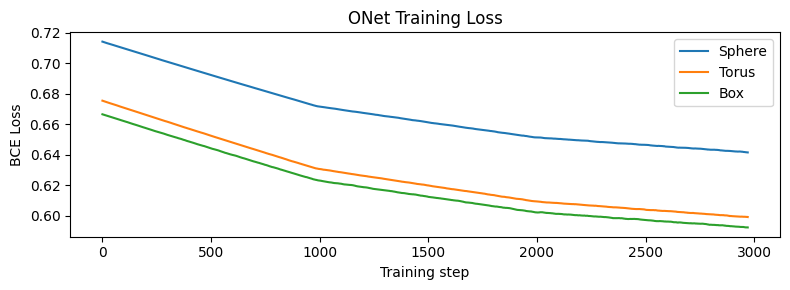

In [11]:
def train_shape(shape_name, n_steps=3000, n_points=4096, c_dim=64,
                hidden_size=256, n_blocks=5, lr=1e-4, verbose=True):
    """
    Train an ONet to represent a single shape.
    Uses a learnable latent vector z (unconditional setting).
    """
    sampler = SHAPES[shape_name]

    decoder = OccupancyDecoder(c_dim=c_dim, hidden_size=hidden_size, n_blocks=n_blocks).to(device)
    z       = nn.Parameter(torch.zeros(1, c_dim, device=device))  # learnable latent

    optimizer = torch.optim.Adam(list(decoder.parameters()) + [z], lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)

    loss_history = []
    for step in range(1, n_steps + 1):
        pts, occ = sampler(n_points)
        pts = pts.unsqueeze(0).to(device)   # (1, N, 3)
        occ = occ.unsqueeze(0).to(device)   # (1, N)

        pred = decoder(pts, z)              # (1, N)
        loss = F.binary_cross_entropy(pred, occ)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        loss_history.append(loss.item())

        if verbose and step % 500 == 0:
            acc = ((pred > 0.5).float() == occ).float().mean().item()
            print(f'  Step {step:4d} | BCE Loss: {loss.item():.4f} | Accuracy: {acc:.3f}')

    return decoder, z.detach(), loss_history


print('Training ONet on sphere...')
decoder_sphere, z_sphere, losses_sphere = train_shape('sphere', n_steps=3000)

print('\nTraining ONet on torus...')
decoder_torus, z_torus, losses_torus = train_shape('torus', n_steps=3000)

print('\nTraining ONet on box...')
decoder_box, z_box, losses_box = train_shape('box', n_steps=3000)

# Plot loss curves
plt.figure(figsize=(8, 3))
for name, losses in [('Sphere', losses_sphere), ('Torus', losses_torus), ('Box', losses_box)]:
    smooth = np.convolve(losses, np.ones(30)/30, mode='valid')
    plt.plot(smooth, label=name)
plt.xlabel('Training step')
plt.ylabel('BCE Loss')
plt.title('ONet Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Mesh Extraction via Marching Cubes

To get a mesh from the learned occupancy function, we:
1. Evaluate `f(p)` on a dense 3D grid
2. Apply **Marching Cubes** at the 0.5 isosurface

The paper uses a smarter hierarchical MISE algorithm, but Marching Cubes on a grid is the conceptual equivalent.

In [16]:
@torch.no_grad()
def extract_mesh(decoder, z, resolution=64, threshold=0.5, batch_size=32768):
    """
    Evaluate the occupancy field on a grid and run Marching Cubes.

    Args:
        resolution: grid resolution (N × N × N)
        threshold:  isosurface level (0.5 = decision boundary)
    Returns:
        verts, faces  (numpy arrays)
    """
    decoder.eval()
    grid_1d = torch.linspace(-1, 1, resolution)
    gx, gy, gz = torch.meshgrid(grid_1d, grid_1d, grid_1d, indexing='ij')
    grid_pts = torch.stack([gx, gy, gz], dim=-1).reshape(-1, 3)  # (N^3, 3)

    # Evaluate in batches to avoid OOM
    occ_vals = []
    for i in range(0, len(grid_pts), batch_size):
        batch = grid_pts[i:i+batch_size].unsqueeze(0).to(device)  # (1, B, 3)
        pred  = decoder(batch, z)   # (1, B)
        occ_vals.append(pred.squeeze(0).cpu())
    occ_grid = torch.cat(occ_vals).reshape(resolution, resolution, resolution).numpy()

    # Marching Cubes
    # Handle cases where the threshold is outside the min/max of the occupancy grid
    if occ_grid.min() >= threshold or occ_grid.max() <= threshold:
        print(f"  Warning: No surface found at threshold {threshold}. Occupancy grid range: [{occ_grid.min():.2f}, {occ_grid.max():.2f}]. Returning empty mesh.")
        return np.array([]), np.array([]), occ_grid

    verts, faces, normals, _ = measure.marching_cubes(occ_grid, level=threshold)
    # Rescale verts from grid coords to [-1, 1]
    verts = verts / (resolution - 1) * 2 - 1
    return verts, faces, occ_grid


def plot_mesh_plotly(verts, faces, title='ONet Mesh', color='lightblue'):
    """Interactive 3D mesh viewer."""
    if verts.shape[0] == 0:
        print(f"  Warning: Cannot plot {title} because verts array is empty.")
        return

    fig = go.Figure(go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        color=color, opacity=0.85,
        lighting=dict(ambient=0.4, diffuse=0.8, specular=0.5),
        lightposition=dict(x=1, y=1, z=2)
    ))
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[-1, 1], title='X'),
            yaxis=dict(range=[-1, 1], title='Y'),
            zaxis=dict(range=[-1, 1], title='Z'),
            aspectmode='cube',
            bgcolor='rgb(20,20,30)'
        ),
        width=500, height=500,
        paper_bgcolor='rgb(20,20,30)',
        font_color='white'
    )
    fig.show()


print('Extracting meshes...')
verts_sphere, faces_sphere, grid_sphere = extract_mesh(decoder_sphere, z_sphere, resolution=64)
verts_torus,  faces_torus,  grid_torus  = extract_mesh(decoder_torus,  z_torus,  resolution=64)
verts_box,    faces_box,    grid_box    = extract_mesh(decoder_box,    z_box,    resolution=64)

print(f'  Sphere: {len(verts_sphere):,} vertices, {len(faces_sphere):,} faces')
print(f'  Torus:  {len(verts_torus):,} vertices,  {len(faces_torus):,} faces')
print(f'  Box:    {len(verts_box):,} vertices,    {len(faces_box):,} faces')

Extracting meshes...
  Sphere: 0 vertices, 0 faces
  Torus:  0 vertices,  0 faces
  Box:    0 vertices,    0 faces


In [17]:
# Interactive 3D mesh views
plot_mesh_plotly(verts_sphere, faces_sphere, title='ONet → Sphere', color='steelblue')
plot_mesh_plotly(verts_torus,  faces_torus,  title='ONet → Torus',  color='mediumseagreen')
plot_mesh_plotly(verts_box,    faces_box,    title='ONet → Box',    color='tomato')

## 6. Occupancy Field Slices

Visualize the learned continuous field as 2D cross-sections (like an MRI).

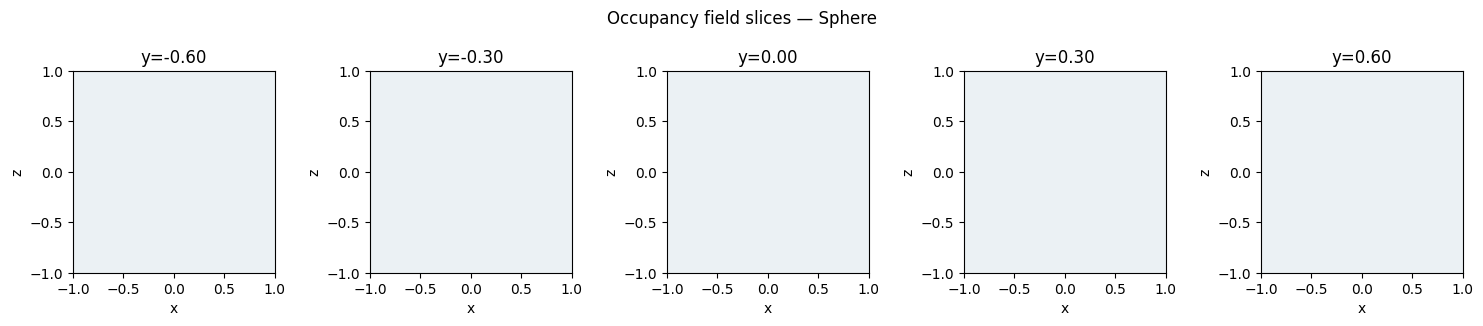

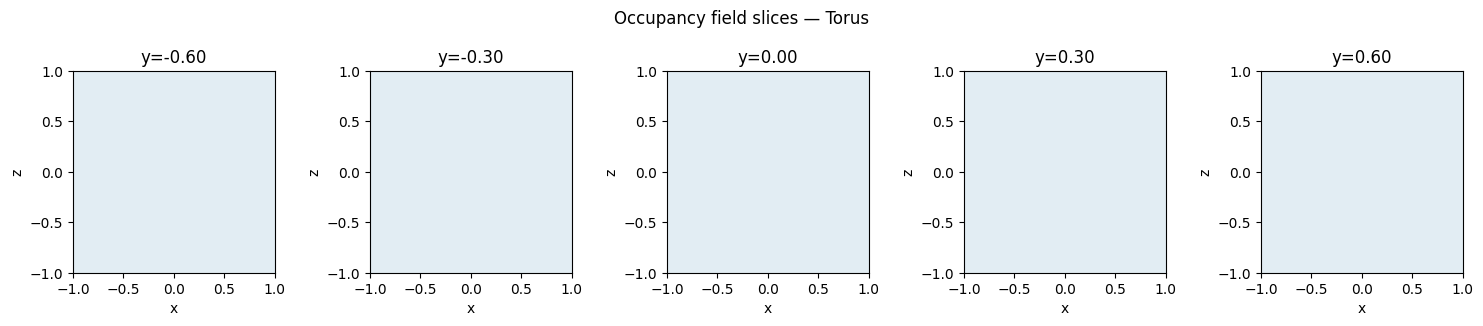

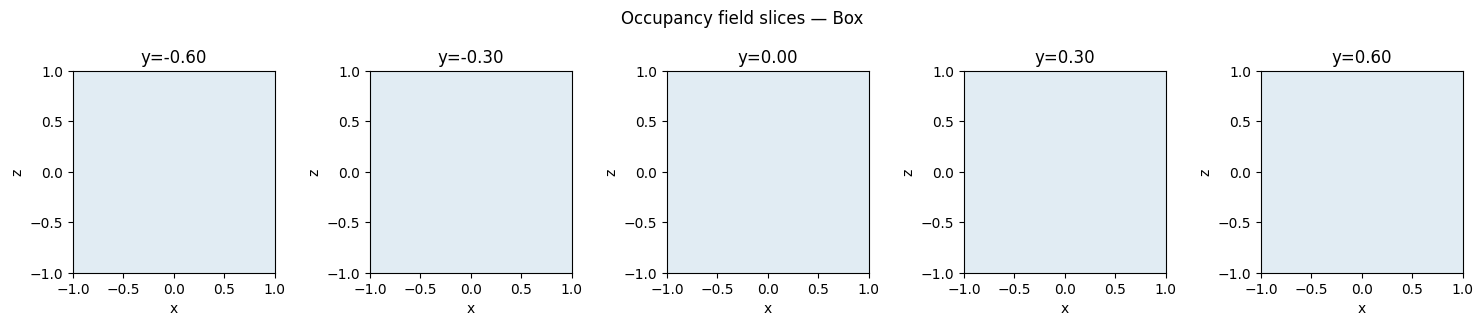

In [18]:
@torch.no_grad()
def plot_field_slices(decoder, z, title, n_slices=5, resolution=128):
    decoder.eval()
    grid_1d = torch.linspace(-1, 1, resolution)
    gx, gz = torch.meshgrid(grid_1d, grid_1d, indexing='ij')

    slice_ys = torch.linspace(-0.6, 0.6, n_slices)
    fig, axes = plt.subplots(1, n_slices, figsize=(3 * n_slices, 3))
    fig.suptitle(f'Occupancy field slices — {title}', y=1.02)

    for ax, sy in zip(axes, slice_ys):
        pts = torch.stack([gx.flatten(),
                           torch.full((resolution*resolution,), sy.item()),
                           gz.flatten()], dim=-1).unsqueeze(0).to(device)
        occ = decoder(pts, z).squeeze(0).reshape(resolution, resolution).cpu().numpy()
        ax.imshow(occ, cmap='RdBu_r', vmin=0, vmax=1, origin='lower',
                  extent=[-1, 1, -1, 1])
        ax.contour(np.linspace(-1,1,resolution), np.linspace(-1,1,resolution),
                   occ.T, levels=[0.5], colors='yellow', linewidths=1.5)
        ax.set_title(f'y={sy:.2f}')
        ax.set_xlabel('x'); ax.set_ylabel('z')
    plt.tight_layout()
    plt.show()

plot_field_slices(decoder_sphere, z_sphere, 'Sphere')
plot_field_slices(decoder_torus,  z_torus,  'Torus')
plot_field_slices(decoder_box,    z_box,    'Box')

## 7. ONet vs. Voxels: Resolution vs. Memory

The key advantage of ONet: **infinite resolution at fixed memory cost**.

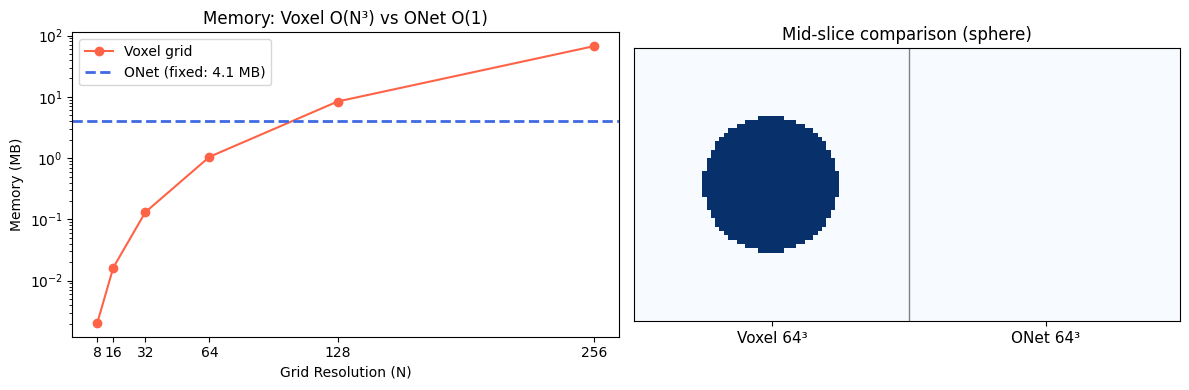

Voxel grid @ 256³ requires: 67 MB
ONet requires:              4.1 MB  (regardless of query resolution!)


In [20]:
resolutions = [8, 16, 32, 64, 128, 256]
voxel_memory_mb  = [r**3 * 4 / 1e6 for r in resolutions]   # float32 bytes
onet_params = sum(p.numel() for p in decoder_sphere.parameters()) * 4 / 1e6

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Memory comparison
axes[0].plot(resolutions, voxel_memory_mb, 'o-', color='tomato', label='Voxel grid')
axes[0].axhline(onet_params, color='royalblue', linestyle='--', linewidth=2,
                label=f'ONet (fixed: {onet_params:.1f} MB)')
axes[0].set_xlabel('Grid Resolution (N)')
axes[0].set_ylabel('Memory (MB)')
axes[0].set_title('Memory: Voxel O(N³) vs ONet O(1)')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_xticks(resolutions)

# Visual quality: voxelised sphere vs ONet sphere at same resolution
res = 64 # Changed from 32 to 64 to match onet_vox resolution
# Ground truth voxels (analytical sphere)
gx = np.linspace(-1, 1, res)
G = np.stack(np.meshgrid(gx, gx, gx, indexing='ij'), axis=-1)
gt_vox = (np.linalg.norm(G, axis=-1) < 0.5).astype(float)
onet_vox = (grid_sphere > 0.5).astype(float)
# Plot mid-slice
mid = res // 2
axes[1].imshow(np.concatenate([gt_vox[:, :, mid], onet_vox[:, :, mid]], axis=1),
               cmap='Blues', origin='lower')
axes[1].axvline(res, color='gray', linewidth=1)
axes[1].set_xticks([res//2, res + res//2])
axes[1].set_xticklabels([f'Voxel {res}³', f'ONet {64}³'], fontsize=11)
axes[1].set_title('Mid-slice comparison (sphere)')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

print(f'Voxel grid @ 256³ requires: {256**3 * 4 / 1e6:.0f} MB')
print(f'ONet requires:              {onet_params:.1f} MB  (regardless of query resolution!)')

## 8. Latent Space Interpolation

Train a small encoder on multiple shapes, then interpolate between their latent codes in `z`-space. The network smoothly morphs between shapes — something impossible with discrete voxels.

In [21]:
# We'll do a simpler latent interpolation:
# sphere and torus are already encoded in z_sphere and z_torus
# Interpolate between them using the sphere decoder

# Train a shared decoder on BOTH sphere and torus with shape-specific latents
C_DIM = 64
shared_decoder = OccupancyDecoder(c_dim=C_DIM, hidden_size=256, n_blocks=5).to(device)

# Two learnable latents
z_A = nn.Parameter(torch.randn(1, C_DIM, device=device) * 0.1)  # sphere
z_B = nn.Parameter(torch.randn(1, C_DIM, device=device) * 0.1)  # torus

optimizer = torch.optim.Adam(
    list(shared_decoder.parameters()) + [z_A, z_B], lr=1e-4
)

N_STEPS = 4000
print(f'Training shared decoder on sphere + torus for {N_STEPS} steps...')
for step in range(1, N_STEPS + 1):
    # Alternate between shapes
    if step % 2 == 0:
        pts, occ = sample_sphere(2048)
        z = z_A
    else:
        pts, occ = sample_torus(2048)
        z = z_B
    pts = pts.unsqueeze(0).to(device)
    occ = occ.unsqueeze(0).to(device)

    pred = shared_decoder(pts, z)
    loss = F.binary_cross_entropy(pred, occ)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        print(f'  Step {step} | Loss: {loss.item():.4f}')

print('Done! Extracting interpolated meshes...')

Training shared decoder on sphere + torus for 4000 steps...
  Step 1000 | Loss: 0.0119
  Step 2000 | Loss: 0.0137
  Step 3000 | Loss: 0.0209
  Step 4000 | Loss: 0.0065
Done! Extracting interpolated meshes...


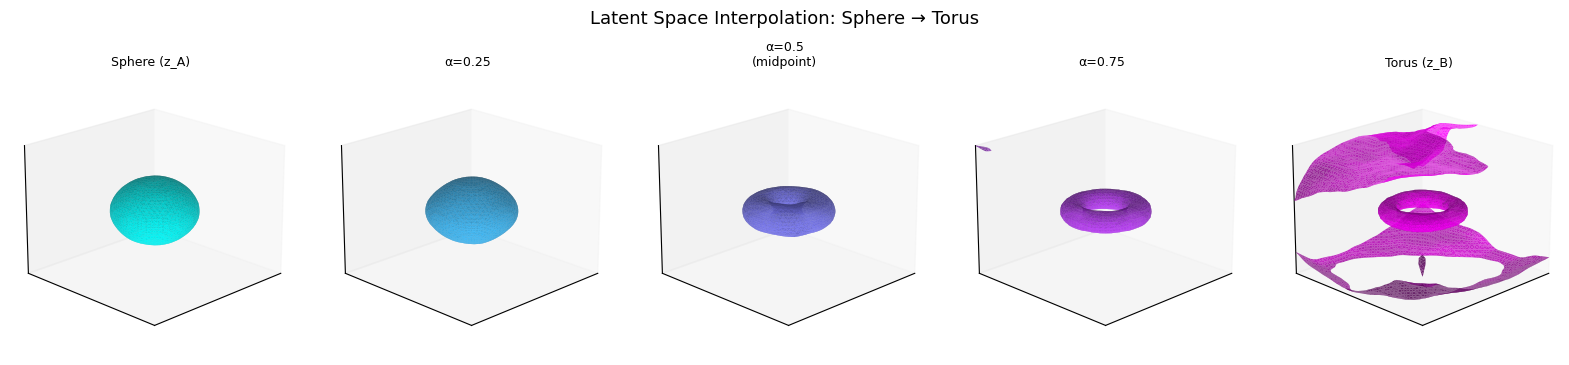

In [22]:
# Extract meshes along the interpolation path
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
interp_meshes = []

for alpha in alphas:
    z_interp = ((1 - alpha) * z_A + alpha * z_B).detach()
    verts, faces, _ = extract_mesh(shared_decoder, z_interp, resolution=48)
    interp_meshes.append((verts, faces, alpha))

# Plot all 5 interpolation steps as subplots
fig = plt.figure(figsize=(16, 3.5))
labels = ['Sphere (z_A)', 'α=0.25', 'α=0.5\n(midpoint)', 'α=0.75', 'Torus (z_B)']

for i, ((verts, faces, alpha), label) in enumerate(zip(interp_meshes, labels)):
    ax = fig.add_subplot(1, 5, i+1, projection='3d')
    ax.plot_trisurf(verts[:, 0], verts[:, 1], verts[:, 2],
                   triangles=faces,
                   color=plt.cm.cool(alpha), alpha=0.85, linewidth=0)
    ax.set_title(label, fontsize=9)
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=20, azim=45)

plt.suptitle('Latent Space Interpolation: Sphere → Torus', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 9. Robustness: Learning from Noisy Point Clouds

ONet can also be conditioned on an encoder. Here we show it recovering a clean shape from a noisy point cloud using the PointNet encoder.

Training encoder-decoder on noisy sphere point cloud...
  Step 1000 | Loss: 0.0143
  Step 2000 | Loss: 0.0084
  Step 3000 | Loss: 0.0073
  Step 4000 | Loss: 0.0070
Extracting reconstruction...


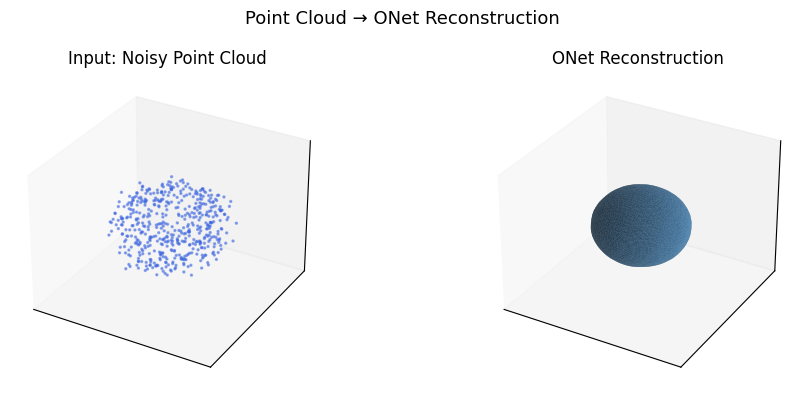

In [23]:
# Sample surface points from sphere with noise
def sample_sphere_surface(n, noise=0.05):
    """Random points on sphere surface + Gaussian noise."""
    pts = torch.randn(n, 3)
    pts = F.normalize(pts, dim=-1) * 0.5
    pts += torch.randn_like(pts) * noise
    return pts

noisy_pc = sample_sphere_surface(512, noise=0.07)

# Build encoder + decoder
encoder_pc = PointNetEncoder(c_dim=128).to(device)
decoder_pc = OccupancyDecoder(c_dim=128, hidden_size=256, n_blocks=5).to(device)

optimizer_pc = torch.optim.Adam(
    list(encoder_pc.parameters()) + list(decoder_pc.parameters()), lr=1e-4
)

print('Training encoder-decoder on noisy sphere point cloud...')
for step in range(1, 4001):
    pts_q, occ_q = sample_sphere(2048)
    pts_q = pts_q.unsqueeze(0).to(device)
    occ_q = occ_q.unsqueeze(0).to(device)

    # Encode the noisy point cloud
    pc_batch = noisy_pc.unsqueeze(0).to(device)
    z_enc = encoder_pc(pc_batch)          # (1, 128)

    pred = decoder_pc(pts_q, z_enc)
    loss = F.binary_cross_entropy(pred, occ_q)
    optimizer_pc.zero_grad()
    loss.backward()
    optimizer_pc.step()

    if step % 1000 == 0:
        print(f'  Step {step} | Loss: {loss.item():.4f}')

print('Extracting reconstruction...')
with torch.no_grad():
    z_enc_final = encoder_pc(noisy_pc.unsqueeze(0).to(device))
verts_rec, faces_rec, _ = extract_mesh(decoder_pc, z_enc_final, resolution=64)

# Visualize
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(*noisy_pc.T.numpy(), s=2, c='royalblue', alpha=0.5)
ax1.set_title('Input: Noisy Point Cloud')
ax1.set_xlim(-1,1); ax1.set_ylim(-1,1); ax1.set_zlim(-1,1)
ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_trisurf(verts_rec[:,0], verts_rec[:,1], verts_rec[:,2],
                triangles=faces_rec, color='steelblue', alpha=0.8, linewidth=0)
ax2.set_title('ONet Reconstruction')
ax2.set_xlim(-1,1); ax2.set_ylim(-1,1); ax2.set_zlim(-1,1)
ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])

plt.suptitle('Point Cloud → ONet Reconstruction', fontsize=13)
plt.tight_layout()
plt.show()